# Visualize Datasets

In [2]:
import anndata as ad
import scanpy as sc
# For saving results on HPC Cluster
import joblib
import pandas as pd
import os

def preprocess_adata(path_to_adata, filtered=False):
    # Load training data
    adata = ad.io.read_h5ad(path_to_adata)

    if not filtered:
        # Filter blood data
        adata = adata[adata.obs['Organ'] == 'BLD'].copy()
        print(adata)
    
        # Use raw data instead of already preprocessed data
        adata.X = adata.layers['counts'].copy()
    
    # Preprocessing
    
    # mitochondrial genes, "MT-" for human, "Mt-" for mouse
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    # ribosomal genes
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    # hemoglobin genes
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
    
    # Remove mitochondrial, ribosomal and hemoglobin
    adata = adata[:, ~adata.var["mt"]].copy()
    adata = adata[:, ~adata.var["ribo"]].copy()
    adata = adata[:, ~adata.var["hb"]].copy()
    
    # Doublet Detection
    sc.pp.scrublet(adata, batch_key="Donor")
    adata = adata[adata.obs['predicted_doublet'] == False].copy()
    
    
    # Normalization
    
    # Saving count data
    adata.layers["counts"] = adata.X.copy()
    
    # Normalizing to median total counts
    sc.pp.normalize_total(adata, target_sum=1e4)
    # Logarithmize the data
    sc.pp.log1p(adata)
    
    # Filtering Highly variable genes
    print('Before filtering highly variable genes ---')
    print(adata)
    
    sc.pp.highly_variable_genes(adata, n_top_genes=10000)
    
    # Apply filter
    adata = adata[:, adata.var['highly_variable']].copy()
    
    print('After filtering highly variable genes ---')
    print(adata)

    return adata

adata_id = preprocess_adata('../data/CellTypistDataset/CountAdded_PIP_global_object_for_cellxgene_annotated.h5ad')
adata_ood = preprocess_adata('../data/humancellatlas/5f29c29a-51c6-435c-8ff0-2b2a9d05ebee/BL_standard_design_annotated_30_000_samples_tmp_test.h5ad', filtered=True)

AnnData object with n_obs × n_vars = 27620 × 36473
    obs: 'Organ', 'Donor', 'Chemistry', 'Cell_category', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'Sex', 'Age_range', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'scumi-annotation'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'Age_range_colors', 'Sex_colors', 'scrublet'
    obsm: 'X_umap'
    layers: 'counts'
Before filtering highly variable genes 

In [3]:
# Filter classes from out-of-distribution dataset that were not in the in-distribution dataset

id_classes = adata_id.obs['scumi-annotation'].unique()

adata_ood = adata_ood[adata_ood.obs['scumi-annotation'].isin(id_classes)].copy()

# Remove unused classes so they don't show up in the plots
if str(adata_ood.obs['scumi-annotation'].dtype) == 'category':
    adata_ood.obs['scumi-annotation'] = adata_ood.obs['scumi-annotation'].cat.remove_unused_categories()

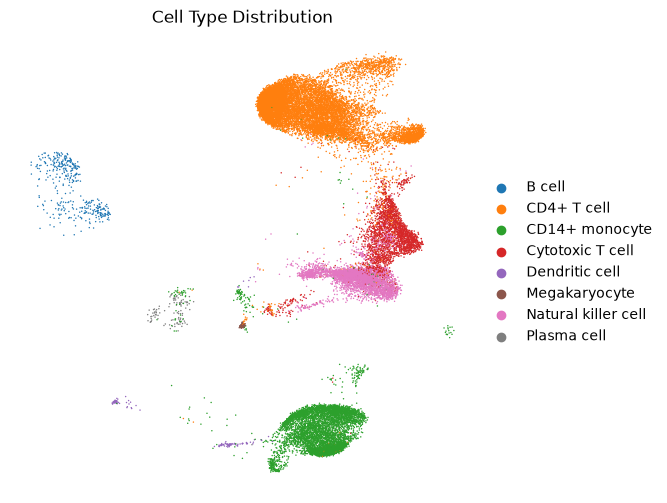

In [9]:
import scanpy as sc
import matplotlib.pyplot as plt

# WICHTIG: Text als editierbaren Text in der SVG behalten (nicht als Pfade)
plt.rcParams['svg.fonttype'] = 'none'

# 1. Falls UMAP noch nicht berechnet ist:
# sc.pp.pca(adata)
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)

# 2. UMAP plotten
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(
    adata_id,
    color='scumi-annotation',       # Ersetze durch deine AnnData.obs-Spalte
    show=False,
    ax=ax,
    frameon=False,           # Entfernt den schwarzen Rahmen um die UMAP (sieht auf Folien cleaner aus)
    title="Cell Type Distribution"
)

# 3. Als SVG speichern
#plt.savefig("umap_motivation.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()

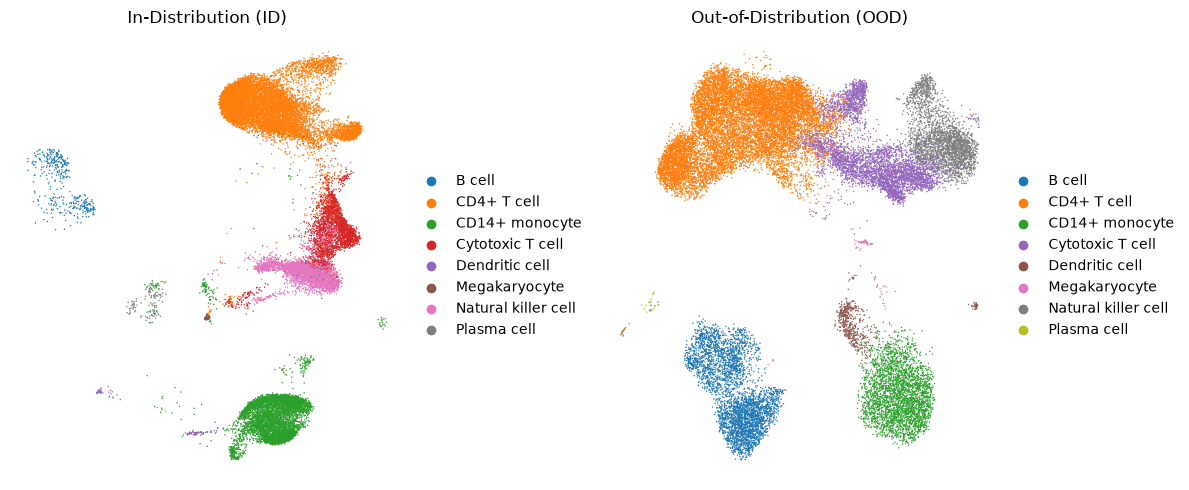

In [12]:
import scanpy as sc
import matplotlib.pyplot as plt

# WICHTIG: Text als editierbaren Text in der SVG behalten (nicht als Pfade)
plt.rcParams['svg.fonttype'] = 'none'

# 1. Figure mit 2 Subplots nebeneinander erstellen (1 Zeile, 2 Spalten)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. Linke UMAP: In-Distribution (adata_id)
sc.pl.umap(
    adata_id,
    color='scumi-annotation',
    title="In-Distribution (ID)",
    show=False,
    ax=axes[0],
    frameon=False
)

# 3. Rechte UMAP: Out-of-Distribution (adata_ood)
sc.pl.umap(
    adata_ood,
    color='scumi-annotation',
    title="Out-of-Distribution (OOD)",
    show=False,
    ax=axes[1],
    frameon=False
)

# Abstände optimieren
plt.tight_layout()

# 4. Als SVG speichern & anzeigen
plt.savefig("umap_id_vs_ood.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()

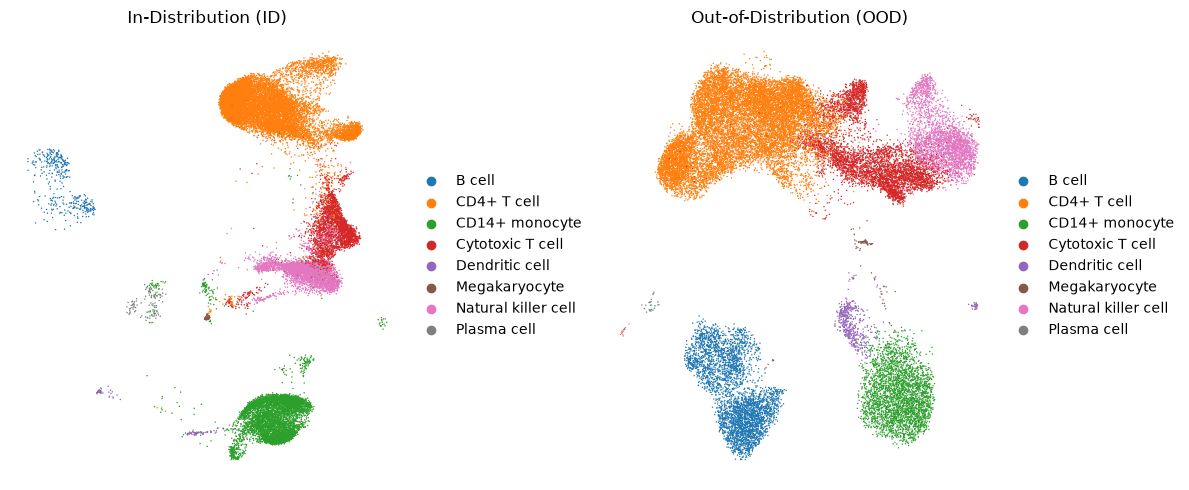

In [14]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'

# Synchronize colors across both distributions
adata_id.obs['scumi-annotation'] = adata_id.obs['scumi-annotation'].astype('category')
id_categories = adata_id.obs['scumi-annotation'].cat.categories

adata_ood.obs['scumi-annotation'] = pd.Categorical(
    adata_ood.obs['scumi-annotation'], 
    categories=id_categories
)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.umap(
    adata_id,
    color='scumi-annotation',
    title="In-Distribution (ID)",
    show=False,
    ax=axes[0],
    frameon=False
)

adata_ood.uns['scumi-annotation_colors'] = adata_id.uns['scumi-annotation_colors']

sc.pl.umap(
    adata_ood,
    color='scumi-annotation',
    title="Out-of-Distribution (OOD)",
    show=False,
    ax=axes[1],
    frameon=False
)

plt.tight_layout()
plt.savefig("umap_id_vs_ood.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()

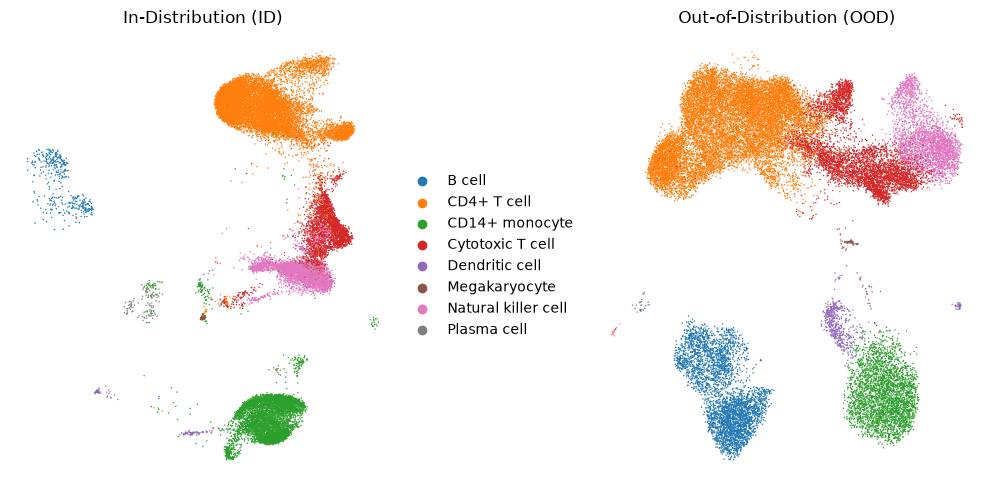

In [4]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

#plt.rcParams['svg.fonttype'] = 'none'

# Synchronize colors across both distributions
adata_id.obs['scumi-annotation'] = adata_id.obs['scumi-annotation'].astype('category')
id_categories = adata_id.obs['scumi-annotation'].cat.categories

adata_ood.obs['scumi-annotation'] = pd.Categorical(
    adata_ood.obs['scumi-annotation'], 
    categories=id_categories
)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sc.pl.umap(
    adata_id,
    color='scumi-annotation',
    title="In-Distribution (ID)",
    show=False,
    ax=axes[0],
    frameon=False
)

adata_ood.uns['scumi-annotation_colors'] = adata_id.uns['scumi-annotation_colors']

sc.pl.umap(
    adata_ood,
    legend_loc=None,
    color='scumi-annotation',
    title="Out-of-Distribution (OOD)",
    show=False,
    ax=axes[1],
    frameon=False
)

plt.tight_layout()
#plt.savefig("umap_id_vs_ood_one_legend.svg", format="svg", bbox_inches="tight", transparent=True)
plt.savefig(
    "umap_id_vs_ood_one_legend.png",
    format="png",
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()

Gemeinsame Gene: 4939


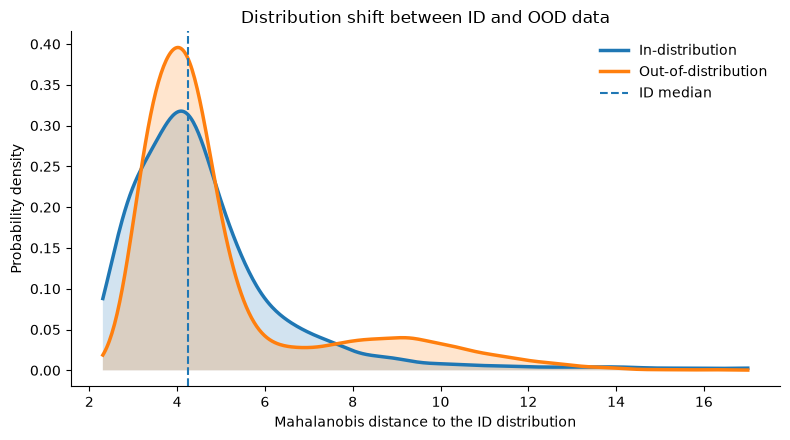

ID:  Median=4.252, Mean=4.828
OOD: Median=4.281, Mean=5.091


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde


def plot_mahalanobis_density(
    adata_id,
    adata_ood,
    layer=None,
    n_components=30,
    max_cells=20_000,
    random_state=42,
    save_path=None,
):
    """
    Erstellt einen Dichteplot der Mahalanobis-Distanzen für ID- und OOD-Daten.

    Die PCA, Standardisierung und Kovarianzmatrix werden ausschließlich
    anhand des ID-Datensatzes bestimmt.

    Parameters
    ----------
    adata_id : anndata.AnnData
        In-Distribution-Datensatz.
    adata_ood : anndata.AnnData
        Out-of-Distribution-Datensatz.
    layer : str or None
        Zu verwendender AnnData-Layer. Bei None wird adata.X verwendet.
        Beispiel: layer="counts" oder layer="log1p".
    n_components : int
        Anzahl der PCA-Komponenten.
    max_cells : int or None
        Maximale Anzahl Zellen pro Datensatz für den Plot.
        Bei None werden alle Zellen verwendet.
    random_state : int
        Seed für reproduzierbares Sampling.
    save_path : str or None
        Optionaler Speicherpfad, z. B. "mahalanobis_density.pdf".

    Returns
    -------
    distances_id : np.ndarray
        Mahalanobis-Distanzen der ID-Zellen.
    distances_ood : np.ndarray
        Mahalanobis-Distanzen der OOD-Zellen.
    """

    rng = np.random.default_rng(random_state)

    # Nur Gene verwenden, die in beiden Datensätzen vorhanden sind
    common_genes = adata_id.var_names.intersection(adata_ood.var_names)

    if len(common_genes) == 0:
        raise ValueError(
            "adata_id und adata_ood besitzen keine gemeinsamen Gene."
        )

    print(f"Gemeinsame Gene: {len(common_genes)}")

    id_common = adata_id[:, common_genes]
    ood_common = adata_ood[:, common_genes]

    def get_matrix(adata):
        if layer is None:
            matrix = adata.X
        else:
            if layer not in adata.layers:
                raise KeyError(
                    f"Layer '{layer}' ist in AnnData nicht vorhanden."
                )
            matrix = adata.layers[layer]

        if sp.issparse(matrix):
            matrix = matrix.toarray()

        return np.asarray(matrix, dtype=np.float32)

    X_id = get_matrix(id_common)
    X_ood = get_matrix(ood_common)

    # Optionales Sampling zur Reduktion von Speicherverbrauch und Plotgröße
    if max_cells is not None:
        if X_id.shape[0] > max_cells:
            indices = rng.choice(
                X_id.shape[0],
                size=max_cells,
                replace=False,
            )
            X_id = X_id[indices]

        if X_ood.shape[0] > max_cells:
            indices = rng.choice(
                X_ood.shape[0],
                size=max_cells,
                replace=False,
            )
            X_ood = X_ood[indices]

    # Anzahl PCA-Komponenten an verfügbare Dimensionen anpassen
    effective_components = min(
        n_components,
        X_id.shape[0] - 1,
        X_id.shape[1],
    )

    if effective_components < 1:
        raise ValueError(
            "Zu wenige Zellen oder Gene für die PCA vorhanden."
        )

    # Skalierung nur anhand der ID-Daten fitten
    scaler = StandardScaler()

    X_id_scaled = scaler.fit_transform(X_id)
    X_ood_scaled = scaler.transform(X_ood)

    # PCA ebenfalls nur anhand der ID-Daten fitten
    pca = PCA(
        n_components=effective_components,
        random_state=random_state,
    )

    X_id_pca = pca.fit_transform(X_id_scaled)
    X_ood_pca = pca.transform(X_ood_scaled)

    # Regularisierte Kovarianzschätzung auf den ID-Daten
    covariance_estimator = LedoitWolf()
    covariance_estimator.fit(X_id_pca)

    id_mean = covariance_estimator.location_
    precision = covariance_estimator.precision_

    def mahalanobis_distance(X):
        difference = X - id_mean

        squared_distances = np.einsum(
            "ij,jk,ik->i",
            difference,
            precision,
            difference,
        )

        # Numerische Rundungsfehler vermeiden
        squared_distances = np.maximum(squared_distances, 0)

        return np.sqrt(squared_distances)

    distances_id = mahalanobis_distance(X_id_pca)
    distances_ood = mahalanobis_distance(X_ood_pca)

    # Gemeinsame x-Achse für beide KDEs
    all_distances = np.concatenate([distances_id, distances_ood])

    lower = np.percentile(all_distances, 0.5)
    upper = np.percentile(all_distances, 99.5)

    x_values = np.linspace(lower, upper, 500)

    kde_id = gaussian_kde(distances_id)
    kde_ood = gaussian_kde(distances_ood)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(
        x_values,
        kde_id(x_values),
        linewidth=2.5,
        label="In-distribution",
    )
    ax.fill_between(
        x_values,
        kde_id(x_values),
        alpha=0.2,
    )

    ax.plot(
        x_values,
        kde_ood(x_values),
        linewidth=2.5,
        label="Out-of-distribution",
    )
    ax.fill_between(
        x_values,
        kde_ood(x_values),
        alpha=0.2,
    )

    ax.axvline(
        np.median(distances_id),
        linestyle="--",
        linewidth=1.5,
        label="ID median",
    )

    ax.set_xlabel("Mahalanobis distance to the ID distribution")
    ax.set_ylabel("Probability density")
    ax.set_title("Distribution shift between ID and OOD data")
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            bbox_inches="tight",
            dpi=300,
        )

    plt.show()

    print(
        f"ID:  Median={np.median(distances_id):.3f}, "
        f"Mean={np.mean(distances_id):.3f}"
    )
    print(
        f"OOD: Median={np.median(distances_ood):.3f}, "
        f"Mean={np.mean(distances_ood):.3f}"
    )

    return distances_id, distances_ood

distances_id, distances_ood = plot_mahalanobis_density(
    adata_id=adata_id,
    adata_ood=adata_ood,
    layer=None,  # oder beispielsweise "counts"
    n_components=30,
    #save_path="id_vs_ood_mahalanobis_density.pdf",
)

In [5]:
from scipy.stats import ks_2samp, wasserstein_distance

ks_result = ks_2samp(distances_id, distances_ood)
wasserstein = wasserstein_distance(distances_id, distances_ood)

print(f"KS statistic: {ks_result.statistic:.3f}")
print(f"KS p-value: {ks_result.pvalue:.3e}")
print(f"Wasserstein distance: {wasserstein:.3f}")

KS statistic: 0.099
KS p-value: 0.000e+00
Wasserstein distance: 0.461
